# Task 2.1: Dataset Selection and Setup

## Paper: "Kernel Methods for Deep Learning" — Cho & Saul (NIPS 2009)

### Dataset Justification

I am using a subset of the **scikit-learn digits dataset** (8×8 grayscale images of handwritten digits 0–9) for testing the arc-cosine kernel. This is a reasonable testbed because the original paper evaluates arc-cosine kernels on image classification tasks involving grayscale pixel inputs (rectangles-image, convex shapes, and MNIST variants), and the digits dataset shares the same fundamental structure — each sample is a flattened vector of pixel intensities representing a handwritten character. The key limitation compared to the paper's datasets is scale and difficulty: the digits dataset has only 1797 samples of 64 features each (8×8 resolution), whereas the paper uses 28×28 images (784 features) with 12,000+ training samples and deliberately challenging backgrounds (random noise, image patches). As a result, the classification task here is considerably easier, and we should expect higher accuracies than those reported in the paper, which is not a sign of a better method but simply a reflection of the simpler problem. Despite this, the dataset is well-suited to verify that the arc-cosine kernel implementation works correctly on image-like data and to observe the effects of kernel degree and depth.

In [1]:
# ============================================================
# HYPERPARAMETERS AND RANDOM SEED (all in one place)
# ============================================================
RANDOM_SEED = 42
TEST_SIZE = 0.3        # 30% held out for testing
VAL_SIZE = 0.15        # 15% of training set used for validation / hyperparameter tuning

import numpy as np
np.random.seed(RANDOM_SEED)

print(f"Random seed set to: {RANDOM_SEED}")
print(f"Test split ratio : {TEST_SIZE}")
print(f"Validation ratio : {VAL_SIZE} (of training set)")

Random seed set to: 42
Test split ratio : 0.3
Validation ratio : 0.15 (of training set)


The cell above sets all hyperparameters and the random seed at the top of the notebook, as required by the reproducibility checklist. This ensures every run produces identical results.

In [2]:
# ============================================================
# LOAD THE DIGITS DATASET
# ============================================================
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data       # shape: (1797, 64) — flattened 8x8 pixel images
y = digits.target     # shape: (1797,)    — digit labels 0-9

print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Dataset loaded: 1797 samples, 64 features
Number of classes: 10
Class distribution: {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}


We load the built-in digits dataset from scikit-learn. Each sample is an 8×8 grayscale image of a handwritten digit (0–9), flattened into a 64-dimensional feature vector. The pixel values range from 0 to 16.

In [3]:
# ============================================================
# PREPROCESSING: Normalize pixel values to [0, 1]
# ============================================================
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature range after scaling: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"Sample feature vector (first 10 values): {X_scaled[0, :10]}")

Feature range after scaling: [0.00, 1.00]
Sample feature vector (first 10 values): [0.     0.     0.3125 0.8125 0.5625 0.0625 0.     0.     0.     0.    ]


We normalize the pixel values from the original [0, 16] range to [0, 1] using MinMaxScaler. This is important for arc-cosine kernels because the kernel value depends on both the angle *and* the magnitude of the inputs (Eq. 3 in the paper: $k_n(x,y) = \frac{1}{\pi}\|x\|^n\|y\|^n J_n(\theta)$). Keeping magnitudes in a consistent range avoids numerical issues, especially for higher-degree kernels (n ≥ 2) where magnitudes are raised to the power 2n.

In [4]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================
from sklearn.model_selection import train_test_split

# First split: train+val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

# Second split: train vs val (from the train+val portion)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_trainval
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"Total         : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} samples")

Training set  : 1068 samples
Validation set: 189 samples
Test set      : 540 samples
Total         : 1797 samples


We split the data into training, validation, and test sets using stratified sampling to preserve the class distribution across splits. The validation set mirrors the paper's methodology (Section 2.4), where the authors used the last 2000 training examples as a validation set to tune the SVM's margin penalty parameter C before retraining on the full training set.

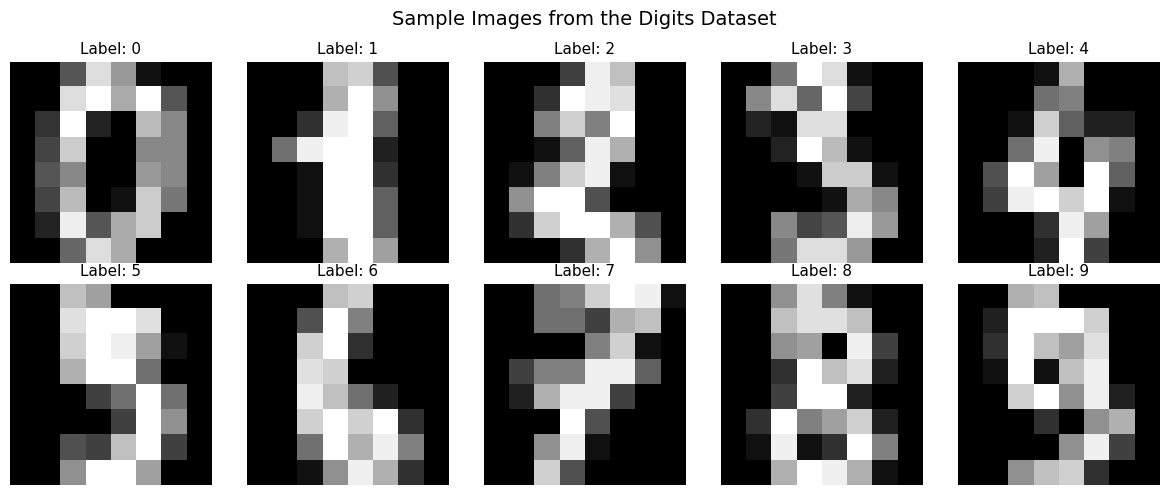

Sample images saved to results/task_2_1_sample_images.png


In [5]:
# ============================================================
# VISUALIZE A FEW SAMPLE IMAGES
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images from the Digits Dataset', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('results/task_2_1_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved to results/task_2_1_sample_images.png")

The visualization above shows 10 sample images from the dataset. Each image is 8×8 pixels — much smaller than the 28×28 images in the paper's experiments. This gives us a quick sanity check that the data is loaded correctly and that the digit labels match the images.